In [3]:
import pandas as pd
df_1 = pd.read_csv('api_data_aadhar_demographic_0_500000.csv')
df_2 = pd.read_csv('api_data_aadhar_demographic_500000_1000000.csv')
df_3 = pd.read_csv('api_data_aadhar_demographic_1000000_1500000.csv')
df_4 = pd.read_csv('api_data_aadhar_demographic_1500000_2000000.csv')
df_5 = pd.read_csv('api_data_aadhar_demographic_2000000_2071700.csv')

combined_df = pd.concat([df_1, df_2, df_3, df_4], ignore_index=True)
print("Shape of combined_df:", combined_df.shape)

Shape of combined_df: (2000000, 6)


In [4]:
combined_df['total_demo'] = combined_df['demo_age_5_17'] + combined_df['demo_age_17_']
display(combined_df.head())

,date,state,district,pincode,demo_age_5_17,demo_age_17_,total_demo
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529,578
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375,397
2,01-03-2025,Gujarat,Rajkot,360006,65,765,830
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314,338
4,01-03-2025,Rajasthan,Udaipur,313801,45,785,830


In [5]:
combined_df =combined_df[combined_df.pincode!=100000]

In [6]:
# state_wise_total_biometric
combined_df['state'] = combined_df['state'].str.strip()
combined_df['state'] = combined_df['state'].str.title()

state_name_mapping = {
    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands','Andaman And Nicobar Islands': 'Andaman and Nicobar Islands','Andaman  Nicobar Islands': 'Andaman and Nicobar Islands','Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu','Dadra And Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu','Dadra  Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu','Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu','Daman  Diu': 'Dadra and Nagar Haveli and Daman and Diu','Dadra And Nagar Haveli And Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli and Daman and Diu': 'Dadra and Nagar Haveli and Daman and Diu','Orissa': 'Odisha','Pondicherry': 'Puducherry','Jammu & Kashmir': 'Jammu and Kashmir','Jammu And Kashmir': 'Jammu and Kashmir',
    'Jammu  Kashmir': 'Jammu and Kashmir', 'West  Bengal': 'West Bengal','West Bengli': 'West Bengal','West Bangal': 'West Bengal','Westbengal': 'West Bengal','The Dadra And Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu','Nct Of Delhi': 'Delhi',
    'Madanapalle': 'Andhra Pradesh','Raja Annamalai Puram': 'Tamil Nadu', 'Nagpur': 'Maharashtra','Jaipur': 'Rajasthan', 'Puttenahalli': 'Karnataka','Darbhanga': 'Bihar','Balanagar': 'Telangana', 'Uttaranchal': 'Uttarakhand','Chhatisgarh': 'Chhattisgarh',
}

combined_df['state'] = combined_df['state'].replace(state_name_mapping)

print(combined_df.head())

         date           state    district  pincode  demo_age_5_17  \
0  01-03-2025   Uttar Pradesh   Gorakhpur   273213             49   
1  01-03-2025  Andhra Pradesh    Chittoor   517132             22   
2  01-03-2025         Gujarat      Rajkot   360006             65   
3  01-03-2025  Andhra Pradesh  Srikakulam   532484             24   
4  01-03-2025       Rajasthan     Udaipur   313801             45   

   demo_age_17_  total_demo  
0           529         578  
1           375         397  
2           765         830  
3           314         338  
4           785         830  


In [7]:
print("Total States : ",len(combined_df['state'].value_counts()))
print(combined_df['state'].value_counts())

Total States :  36
state
Andhra Pradesh                              199499
Tamil Nadu                                  190683
West Bengal                                 162806
Uttar Pradesh                               162187
Maharashtra                                 155615
Karnataka                                   149364
Kerala                                      102381
Odisha                                      102230
Bihar                                        94104
Gujarat                                      92904
Rajasthan                                    86860
Telangana                                    85986
Madhya Pradesh                               73517
Assam                                        60560
Punjab                                       48149
Jharkhand                                    38474
Chhattisgarh                                 34426
Haryana                                      27660
Himachal Pradesh                             27115
Uttara

In [8]:
# Step 1: Identify variations and misspellings in district names
district_name_mapping = {
    # Haryana & Punjab
    "Gurgaon":"Gurugram","Mewat":"Nuh","Yamuna Nagar":"Yamunanagar","Rupnagar":"Rupnagar","Sas Nagar Mohali":"Sahibzada Ajit Singh Nagar","Sas Nagarmohali":"Sahibzada Ajit Singh Nagar","Mohali":"Sahibzada Ajit Singh Nagar","Ferozepur":"Firozpur","Sri Muktsar Sahib":"Sri Muktsar Sahib","Muktsar":"Sri Muktsar Sahib","Nawanshahr":"Shaheed Bhagat Singh Nagar",
    # Sikkim
    "East":"East Sikkim","West":"West Sikkim","North":"North Sikkim","South":"South Sikkim","Namchi":"South Sikkim","Mangan":"North Sikkim",
    # Rajasthan
    "Chittaurgarh":"Chittorgarh","Dhaulpur":"Dholpur","Jhunjhunun":"Jhunjhunu","Ganganagar":"Sri Ganganagar","Shri Ganganagar":"Sri Ganganagar","Jalor":"Jalore","DidwanaKuchaman":"Didwana-Kuchaman","Didwana Kuchaman":"Didwana-Kuchaman","KotputliBehror":"Kotputli-Behror","Kotputli Behror":"Kotputli-Behror","KhairthalTijara":"Khairthal-Tijara",
    "Khairthal Tijara":"Khairthal-Tijara","Neemkathana":"Neem Ka Thana","Neem KaThana":"Neem Ka Thana","GangapurCity":"Gangapur City","Near Meera Hospital":"Jaipur","Jaipur (Rural)":"Jaipur Rural","Udaipur (Rural)":"Udaipur Rural","Jodhpur (Rural)":"Jodhpur Rural","Alwar (Rural)":"Alwar Rural","Sikar (Rural)":"Sikar Rural","Beawar":"Beawar","Phalodi":"Phalodi","Balotra":"Balotra","Salumbar":"Salumbar","Deeg":"Deeg",
    # Maharashtra
    "Chhatrapati Sambhajinagar":"Chhatrapati Sambhajinagar","Chatrapati Sambhaji Nagar":"Chhatrapati Sambhajinagar","Aurangabadbh":"Chhatrapati Sambhajinagar","Aurangabad":"Chhatrapati Sambhajinagar","Raigarhmh":"Raigad","Gondiya":"Gondia","Ahilyanagar":"Ahmednagar","Ahmadnagar":"Ahmednagar","Ahmed Nagar":"Ahmednagar","Near Uday Nagar Nit Garden":"Mumbai","Mumbai City":"Mumbai",
    "Mumbai Suburban":"Mumbai","Mumbai Sub Urban":"Mumbai","Dist Thane":"Thane","Dist  Thane":"Thane","Buldana":"Buldhana","Osmanabad":"Dharashiv","Dharashiv":"Dharashiv","Bid":"Beed","Nandurbar ":"Nandurbar","Washim ":"Washim","Hingoli ":"Hingoli",
    # Madhya Pradesh
    "Hoshangabad":"Narmadapuram","East Nimar":"Khandwa","West Nimar":"Khargone","Narsimhapur":"Narsinghpur","Harda ":"Harda",
    # Uttar Pradesh
    "Allahabad":"Prayagraj","Allahabad ":"Prayagraj","Bara Banki":"Barabanki","Bagpat":"Baghpat","Baghpat ":"Baghpat","Bulandshahar":"Bulandshahr","Bulandshahar":"Bulandshahr","Sant Ravidas Nagar Bhadohi":"Bhadohi","Sant Ravidas Nagar":"Bhadohi","Jyotiba Phule Nagar":"Amroha","Jyotiba  phule Nagar":"Amroha","Jyotiba phule Nagar ":"Amroha","Jyotiba Phule Nagar ":"Amroha","Amorha":"Amroha","Faizabad":"Ayodhya","Hardwar":"Haridwar",
    "Garhwal":"Pauri Garhwal","Chandauli ":"Chandauli","Chitrakoot ":"Chitrakoot","Kushinagar ":"Kushinagar","Shrawasti":"Shravasti","Sant Kabirnagar":"Sant Kabir Nagar","Raebareli":"Rae Bareli","Mahrajganj":"Maharajganj","Kheri":"Lakhimpur Kheri",
    # West Bengal
    "Schim Medinipur":"Paschim Medinipur","West Medinipur":"Paschim Medinipur","West Midnapore":"Paschim Medinipur","Medinipur":"Paschim Medinipur","East Midnapore":"Purba Medinipur","East Midnapur":"Purba Medinipur","Barddhaman":"Purba Bardhaman","Bardhaman":"Purba Bardhaman","South Twenty Four Parganas":"South 24 Parganas","South Twenty Four Pargana":"South 24 Parganas","South Pargana":"South 24 Parganas","South Parganas":"South 24 Parganas",
    "South  Parganas":"South 24 Parganas","South  Twenty Four Parganas":"South 24 Parganas","South  Pargana":"South 24 Parganas","North Twenty Four Parganas":"North 24 Parganas","North Parganas":"North 24 Parganas","North  Parganas":"North 24 Parganas","South Dumdum":"North 24 Parganas","South Dumdumm":"North 24 Parganas","Naihati Anandabazar":"North 24 Parganas","North Dinajpur":"Uttar Dinajpur","South Dinajpur":"Dakshin Dinajpur",
    "Haora":"Howrah","Hawrah":"Howrah","Domjur":"Howrah","Bally Jagachha":"Howrah","Hugli":"Hooghly","Hooghiy":"Hooghly","Puruliya":"Purulia","Darjiling":"Darjeeling","Koch Bihar":"Cooch Behar","Maldah":"Malda",
    # Gujarat & HP
    "Ahmadabad":"Ahmedabad","Sabar Kantha":"Sabarkantha","Surendra Nagar":"Surendranagar","Banas Kantha":"Banaskantha","Dohad":"Dahod","Panch Mahals":"Panchmahal","Panchmahals":"Panchmahal","Lahul And Spiti":"Lahaul And Spiti","Lahul  Spiti":"Lahaul And Spiti",
    # Jharkhand
    "Sahebganj":"Sahibganj","Kodarma":"Koderma","Hazaribagh":"Hazaribag","Pakaur":"Pakur","Palamau":"Palamu","Purbi Singhbhum":"East Singhbhum","Pashchimi Singhbhum":"West Singhbhum","Seraikelakharsawan":"Seraikela Kharsawan","Garhwa ":"Garhwa","Deoghar":"Deoghar",
    # J&K & Uttarakhand
    "Badgam":"Budgam","Punch":"Poonch","Baramula":"Baramulla","Bandipur":"Bandipora","Bandipore":"Bandipora","Shupiyan":"Shopian","Rajauri":"Rajouri"," Jammu":"Jammu","Samba ":"Samba","TerihGarhwal":"Tehri Garhwal","PauriGarhwal":"Pauri Garhwal","UdhamSinghNagar":"Udham Singh Nagar"," Udham Singh Nagar":"Udham Singh Nagar","Udham Singh Nagar ":"Udham Singh Nagar",
    # Telangana
    "Medchalmalkajgiri":"Medchal-Malkajgiri","Medchal-Malkajgiri":"Medchal-Malkajgiri","Medchal–Malkajgiri":"Medchal-Malkajgiri","Idpl Colony":"Medchal-Malkajgiri","Kv Rangareddy":"Rangareddy","Jagitial":"Jagtial","Yadadri":"Yadadri Bhuvanagiri","Komaram Bheem":"Komaram Bheem Asifabad","Mahbubnagar":"Mahabubnagar","Jangoan":"Jangaon","Warangal Urban":"Warangal","Warangal Rural":"Warangal",
    # Tamil Nadu
    "Kancheepuram":"Kanchipuram","Kanniyakumari":"Kanyakumari","Viluppuram":"Villupuram","Thiruvallur":"Tiruvallur","Tiruvarur":"Thiruvarur","Tuticorin":"Thoothukudi","Thoothukkudi":"Thoothukudi","Tirupathur":"Tirupattur","The Nilgiris":"Nilgiris","Near Dhyana Ashram":"Chennai",
    # Delhi
    "North East":"North East Delhi","Najafgarh":"South West Delhi",
    # Andaman & Nicobar
    "Andamans":"South Andaman","North And Middle Andaman":"North and Middle Andaman","Nicobars":"Nicobar",
    # Odisha
    "Nabarangapur":"Nabarangpur","Baleshwar":"Balasore","Baleswar":"Balasore","Khorda":"Khordha","Balianta":"Khordha","Anugul":"Angul","Anugal":"Angul","Baudh":"Boudh","Jagatsinghapur":"Jagatsinghpur","Sundergarh":"Sundargarh","Debagarh":"Deogarh","Sonapur":"Subarnapur","Jajapur":"Jajpur","Jajapur ":"Jajpur","Jajapur  ":"Jajpur","Bhadrakr":"Bhadrak",
    # Nagaland & Mizoram
    "Chumukedima":"Chumukedima","Niuland":"Niuland","Meluri":"Meluri","Tseminyu":"Tseminyu","Shamator":"Shamator","Mammit":"Mamit",
    # Meghalaya
    "Jaintia Hills":"East Jaintia Hills","Eastern West Khasi Hills":"Eastern West Khasi Hills","East Jaintia":"East Jaintia Hills","West Jaintia":"West Jaintia Hills","East Khasi":"East Khasi Hills","West Khasi":"West Khasi Hills","South West Khasi":"South West Khasi Hills","North Garo":"North Garo Hills","East Garo":"East Garo Hills","West Garo":"West Garo Hills","South Garo":"South Garo Hills",
    # Karnataka
    "Tumkur":"Tumakuru","Shimoga":"Shivamogga","Belgaum":"Belagavi","Bengaluru":"Bengaluru Urban","Bangalore":"Bengaluru Urban","Bangalore Rural":"Bengaluru Rural","Mysore":"Mysuru","Bijapur":"Vijayapura","Gulbarga":"Kalaburagi","Bellary":"Ballari","Chikmagalur":"Chikkamagaluru","Bagalkote":"Bagalkot","Bagalkot ":"Bagalkot","Coorg":"Kodagu","Chamarajanagar ":"Chamarajanagar","Udupi ":"Udupi","Gadag ":"Gadag","Haveri ":"Haveri",
    # Goa
    "Bardez":"North Goa","Tiswadi":"North Goa","Bicholim":"North Goa",
    # Chhattisgarh
    "Kabeerdham":"Kabirdham","Kawardha":"Kabirdham","Uttar Bastar Kanker":"Kanker","Dakshin Bastar Dantewada":"Dantewada","Gaurelapendramarwahi":"Gaurela-Pendra-Marwahi","Mohlamanpurambagarh Chouki":"Mohla-Manpur-Ambagarh Chowki","Mohallamanpurambagarh Chowki":"Mohla-Manpur-Ambagarh Chowki",
    "Manendragarhchirmiribharatpur":"Manendragarh-Chirmiri-Bharatpur","Khairagarh Chhuikhadan Gandai":"Khairagarh-Chhuikhadan-Gandai","Janjgirchampa":"Janjgir-Champa","Janjgir Champa":"Janjgir-Champa","Janjgir  Champa":"Janjgir-Champa","Gariyaband":"Gariaband","Sarangarhbilaigarh":"Sarangarh-Bilaigarh",
    # Bihar
    "Kaimur Bhabua":"Kaimur","Bhabua":"Kaimur","Purba Champaran":"East Champaran","Pashchim Champaran":"West Champaran","Purnea":"Purnia","Sheikpura":"Sheikhpura","Samstipur":"Samastipur","Monghyr":"Munger","Near University Thana":"Patna",
    # Assam
    "Guwahati":"Kamrup Metropolitan","Kamrup Metro":"Kamrup Metropolitan","Silchar":"Cachar","Tezpur":"Sonitpur","Marigaon":"Morigaon","Sibsagar":"Sivasagar","Sribhumi":"Sivasagar","South Salmara Mankachar":"South Salmara-Mankachar","North Cachar Hills":"Dima Hasao","Bajali":"Barpeta","Tamulpur District":"Tamulpur",
    # Kerala & Tripura
    "Kasargod":"Kasaragod","Dhalai ":"Dhalai","Dhalai  ":"Dhalai","Alluri Sitharama Raju": "Alluri Sitharama Raju","Anakapalli": "Anakapalli","Anantapur": "Anantapur",
    "Ananthapur": "Anantapur",
    "Ananthapuramu": "Anantapur",
    "Annamayya": "Annamayya",
    "Bapatla": "Bapatla",
    "Chittoor": "Chittoor",
    "Cuddapah": "Y. S. R.",
    "Kadapa": "Y. S. R.",
    "YSR Kadapa": "Y. S. R.",
    "Y. S. R.": "Y. S. R.",
    "Dr. B. R. Ambedkar Konaseema": "Dr. B. R. Ambedkar Konaseema",
    "Konaseema": "Dr. B. R. Ambedkar Konaseema",
    "East Godavari": "East Godavari",
    "Eluru": "Eluru",
    "Guntur": "Guntur",
    "Kakinada": "Kakinada",
    "Krishna": "Krishna",
    "Kurnool": "Kurnool",
    "N. T. R": "N. T. R.",
    "NTR": "N. T. R.",
    "Nandyal": "Nandyal",
    "Nellore": "Sri Potti Sriramulu Nellore",
    "Sri Potti Sriramulu Nellore": "Sri Potti Sriramulu Nellore",
    "Palnadu": "Palnadu",
    "Parvathipuram Manyam": "Parvathipuram Manyam",
    "Prakasam": "Prakasam",
    "Sri Sathya Sai": "Sri Sathya Sai",
    "Srikakulam": "Srikakulam",
    "Tirupati": "Tirupati",
    "Visakhapatnam": "Visakhapatnam","Vizianagaram": "Vizianagaram","West Godavari": "West Godavari",
     # Andhra Pradesh
    "Y. S. R": "Y. S. R.",
    "Rangareddi": "Rangareddy",
    "K.V.Rangareddy": "K.V. Rangareddy",
    "Kadiri Road": None,
    "Karim Nagar": "Karimnagar",
    "Mahabub Nagar": "Mahabubnagar",

    # Bihar
    "Aurangabad(Bh)": "Aurangabad",
    "Kaimur": "Kaimur (Bhabua)",

    # Chhattisgarh
    "Janjgir - Champa": "Janjgir-Champa",
    "Mohalla-Manpur-Ambagarh Chowki": "Mohla-Manpur-Ambagarh Chouki",

    # Dadra and Nagar Haveli and Daman and Diu
    "Dadra & Nagar Haveli": "Dadra And Nagar Haveli",

    # Gujarat
    "Mahesana": "Mehsana",
    "Arvalli": "Aravalli",

    # Himachal Pradesh
    "Lahul & Spiti": "Lahaul And Spiti",

    # Jammu and Kashmir
    "Leh (Ladakh)": "Leh",

    # Jharkhand
    "Garhwa *": "Garhwa",

    # Karnataka
    "Chickmagalur": "Chikkamagaluru",
    "Hasan": "Hassan",
    "Chamrajanagar": "Chamarajanagar",
    "Chamrajnagar": "Chamarajanagar",
    "Davanagere": "Davangere",
    "Bijapur(Kar)": "Vijayapura",
    "Gadag *": "Gadag",
    "Haveri *": "Haveri",
    "Bagalkot *": "Bagalkot",
    "Chamarajanagar *": "Chamarajanagar",
    "Udupi *": "Udupi",
    "Bengaluru South": None,
    "5Th Cross": None,

    # Madhya Pradesh
    "Harda *": "Harda",

    # Maharashtra
    "Gondiya *": "Gondia",
    "Nandurbar *": "Nandurbar",
    "Washim *": "Washim",
    "Hingoli *": "Hingoli",
    "Mumbai( Sub Urban )": "Mumbai Suburban",
    "Raigarh(Mh)": "Raigad",
    "Dist : Thane": "Thane",

    # Odisha
    "Jajapur  *": "Jajpur",
    "Bhadrak(R)": "Bhadrak",

    # Puducherry
    "Pondicherry": "Puducherry",

    # Punjab
    "S.A.S Nagar(Mohali)": "Sas Nagar (Mohali)",

    # Telangana
    "Yadadri.": "Yadadri Bhuvanagiri",
    "Medchal?Malkajgiri": "Medchal-Malkajgiri",
    "Medchal−Malkajgiri": "Medchal-Malkajgiri",
    "Warangal (Urban)": "Hanamkonda",
    "K.V. Rangareddy": "Rangareddy",

    # Tripura
    "Dhalai  *": "Dhalai",

    # Uttar Pradesh
    "Kushinagar *": "Kushinagar",
    "Baghpat *": "Baghpat",
    "Jyotiba Phule Nagar *": "Amroha",
    "Chitrakoot *": "Chitrakoot",
    "Chandauli *": "Chandauli",

    # Uttarakhand
    "Udham Singh Nagar *": "Udham Singh Nagar",

    # West Bengal
    "South 24 Pargana": "South 24 Parganas",
    "South Dumdum(M)": None,
}
combined_df['district'] = combined_df['district'].astype(str).str.strip().str.title()
combined_df['district'] = combined_df['district'].replace(district_name_mapping)
telangana_districts = [
    'Adilabad', 'Bhadradri Kothagudem', 'Hyderabad', 'Jagtial', 'Jangaon',    'Jayashankar Bhupalpally', 'Jogulamba Gadwal', 'Kamareddy', 'Karimnagar',    'Khammam', 'Komaram Bheem', 'Mahabubabad', 'Mahabubnagar', 'Mancherial',    'Medak', 'Medchal', 'Mulugu', 'Nagarkurnool', 'Nalgonda', 'Narayanpet',    'Nirmal', 'Nizamabad', 'Peddapalli', 'Rajanna Sircilla', 'Ranga Reddy',    'Sangareddy', 'Siddipet', 'Suryapet', 'Vikarabad', 'Wanaparthy','Warangal', 'Yadadri Bhuvanagiri'
]
combined_df.loc[
    (combined_df['state'] == 'Andhra Pradesh') & (combined_df['district'].isin(telangana_districts)),
    'state'] = 'Telangana'
combined_df.loc[combined_df['district'] == 'Raigarh', 'state'] = 'Chhattisgarh'
state_district_wise_total_demo = combined_df.groupby(['state','district'])['total_demo'].sum().reset_index()
state_wise_total_demo = combined_df.groupby('state')['total_demo'].sum().reset_index().sort_values('total_demo', ascending=False)
combined_df.loc[combined_df['district'] == 'Raigad', 'state'] = 'Maharashtra'
state_district_wise_total_demo = combined_df.groupby(['state','district'])['total_demo'].sum().reset_index()
state_wise_total_demo = combined_df.groupby('state')['total_demo'].sum().reset_index().sort_values('total_demo', ascending=False)
combined_df.loc[combined_df['district'] == 'Chhatrapati Sambhajinagar', 'state'] = 'Maharashtra'
state_district_wise_total_demo = combined_df.groupby(['state','district'])['total_demo'].sum().reset_index()
state_wise_total_demo = combined_df.groupby('state')['total_demo'].sum().reset_index().sort_values('total_demo', ascending=False)
state_district_wise_total_demo = combined_df.groupby(['state', 'district'])['total_demo'].sum().reset_index()
state_wise_total_demo = combined_df.groupby(['state'])['total_demo'].sum().reset_index().sort_values(by='total_demo', ascending=False)

In [9]:
# user_district = input("Enter the district name you want to modify: ").strip()
# new_state_name = input("Enter the new state name for the specified district: ").strip()

# # Get unique pincodes for the given district
# pincodes_in_district = combined_df[combined_df['district'] == user_district]['pincode'].unique()

# if len(pincodes_in_district) == 0:
#     print(f"No pincodes found for district '{user_district}'. Please check the district name and try again.")
# else:
#     # Update the state for all entries with these pincodes
#     combined_df.loc[combined_df['pincode'].isin(pincodes_in_district), 'state'] = new_state_name
#     print(f"All entries with pincodes from district '{user_district}' (Pincodes: {pincodes_in_district}) have been assigned to state '{new_state_name}'.")

#     # Re-calculate aggregated dataframes
#     state_district_wise_total_biometric = combined_df.groupby(['state', 'district'])['total_biometric'].sum().reset_index()
#     state_wise_total_biometric = combined_df.groupby(['state'])['total_biometric'].sum().reset_index().sort_values(by='total_biometric', ascending=False)

#     print("Aggregated data (state-wise and state-district-wise total biometric) has been re-calculated.")
#     print("Updated state_wise_total_biometric head:")
#     print(state_wise_total_biometric.head())

In [10]:
# wrong_district_name = input("Enter the incorrect district name to be updated: ").strip().title()
# correct_district_name = input("Enter the correct district name: ").strip().title()

# if wrong_district_name in combined_df['district'].unique():
#     combined_df['district'] = combined_df['district'].replace(wrong_district_name, correct_district_name)
#     print(f"All occurrences of district '{wrong_district_name}' have been updated to '{correct_district_name}'.")

#     # Re-calculate aggregated dataframes to reflect the changes
#     state_district_wise_total_biometric = combined_df.groupby(['state', 'district'])['total_biometric'].sum().reset_index()
#     state_wise_total_biometric = combined_df.groupby(['state'])['total_biometric'].sum().reset_index().sort_values(by='total_biometric', ascending=False)

#     print("Aggregated data (state-wise and state-district-wise total biometric) has been re-calculated.")
#     print("Updated state_district_wise_total_biometric head:")
#     print(state_district_wise_total_biometric.head())
# else:
#     print(f"District '{wrong_district_name}' not found in the DataFrame. Please check the name and try again.")


In [11]:
selected_state = input("Enter the state name to list its districts: ")
districts_in_selected_state = state_district_wise_total_demo[state_district_wise_total_demo['state'] == selected_state]
if not districts_in_selected_state.empty:
    unique_districts = districts_in_selected_state['district'].unique()
    print(f"\nDistricts in {selected_state}:")
    for district in unique_districts:
        print(f"- {district}")
    print(f"\nTotal districts found in {selected_state}: {len(unique_districts)}")
else:
    print(f"No districts found for the state: {selected_state}. Please check the state name and try again.")

KeyboardInterrupt: Interrupted by user

In [12]:
state_district_map = combined_df.groupby('state')['district'].unique().apply(list).to_dict()
print(state_district_map)

{'Andaman and Nicobar Islands': ['South Andaman', 'North and Middle Andaman', 'Nicobar'], 'Andhra Pradesh': ['Chittoor', 'Srikakulam', 'Kurnool', 'Alluri Sitharama Raju', 'Prakasam', 'Anantapur', 'Visakhapatnam', 'East Godavari', 'Annamayya', 'Anakapalli', 'Krishna', 'Parvathipuram Manyam', 'West Godavari', 'Nandyal', 'Y. S. R.', 'Vizianagaram', 'Kakinada', 'Palnadu', 'N. T. R.', 'Eluru', 'Dr. B. R. Ambedkar Konaseema', 'Guntur', 'Bapatla', 'Rangareddy', 'Sri Sathya Sai', 'Sri Potti Sriramulu Nellore', 'Tirupati', 'K.V. Rangareddy', None], 'Arunachal Pradesh': ['West Kameng', 'Tawang', 'Lohit', 'Kra Daadi', 'Upper Siang', 'Anjaw', 'Changlang', 'East Siang', 'Kamle', 'Longding', 'West Siang', 'Namsai', 'Tirap', 'Upper Subansiri', 'East Kameng', 'Kurung Kumey', 'Lower Siang', 'Lower Subansiri', 'Papum Pare', 'Siang', 'Dibang Valley', 'Lower Dibang Valley', 'Leparada', 'Shi-Yomi', 'Pakke Kessang'], 'Assam': ['Tinsukia', 'Charaideo', 'Udalguri', 'Nalbari', 'Karimganj', 'Nagaon', 'Lakhimpur

In [13]:
num_districts_per_state = {state: len(districts) for state, districts in state_district_map.items()}
print("Total number of districts in each state:")
print(num_districts_per_state)

Total number of districts in each state:
{'Andaman and Nicobar Islands': 3, 'Andhra Pradesh': 29, 'Arunachal Pradesh': 25, 'Assam': 34, 'Bihar': 39, 'Chandigarh': 3, 'Chhattisgarh': 33, 'Dadra and Nagar Haveli and Daman and Diu': 3, 'Delhi': 11, 'Goa': 2, 'Gujarat': 33, 'Haryana': 22, 'Himachal Pradesh': 12, 'Jammu and Kashmir': 22, 'Jharkhand': 24, 'Karnataka': 32, 'Kerala': 14, 'Ladakh': 2, 'Lakshadweep': 1, 'Madhya Pradesh': 55, 'Maharashtra': 36, 'Manipur': 13, 'Meghalaya': 12, 'Mizoram': 11, 'Nagaland': 17, 'Odisha': 30, 'Puducherry': 3, 'Punjab': 23, 'Rajasthan': 41, 'Sikkim': 4, 'Tamil Nadu': 38, 'Telangana': 34, 'Tripura': 8, 'Uttar Pradesh': 75, 'Uttarakhand': 13, 'West Bengal': 24}


In [14]:
state_wise_total_demo = combined_df.groupby(['state'])['total_demo'].sum().reset_index().sort_values(by='total_demo', ascending=False)
print("head : ")
print(state_wise_total_demo.head())
print()
print()
print("tail : ")
print(state_wise_total_demo.tail())

head : 
             state  total_demo
33   Uttar Pradesh     8364554
20     Maharashtra     4952803
4            Bihar     4606322
35     West Bengal     3795517
19  Madhya Pradesh     2867114


tail : 
                                       state  total_demo
29                                    Sikkim       20143
7   Dadra and Nagar Haveli and Daman and Diu       11993
0                Andaman and Nicobar Islands        7000
17                                    Ladakh        5627
18                               Lakshadweep        1159


In [15]:
state_district_wise_Demo = combined_df.groupby(['state', 'district'])['total_demo'].sum().reset_index()
print(state_district_wise_total_demo.head())

                         state                  district  total_demo
0  Andaman and Nicobar Islands                   Nicobar         789
1  Andaman and Nicobar Islands  North and Middle Andaman        1935
2  Andaman and Nicobar Islands             South Andaman        4276
3               Andhra Pradesh     Alluri Sitharama Raju       12554
4               Andhra Pradesh                Anakapalli       13062


C:\Users\kshit\AppData\Local\Temp\ipykernel_9560\2874037709.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


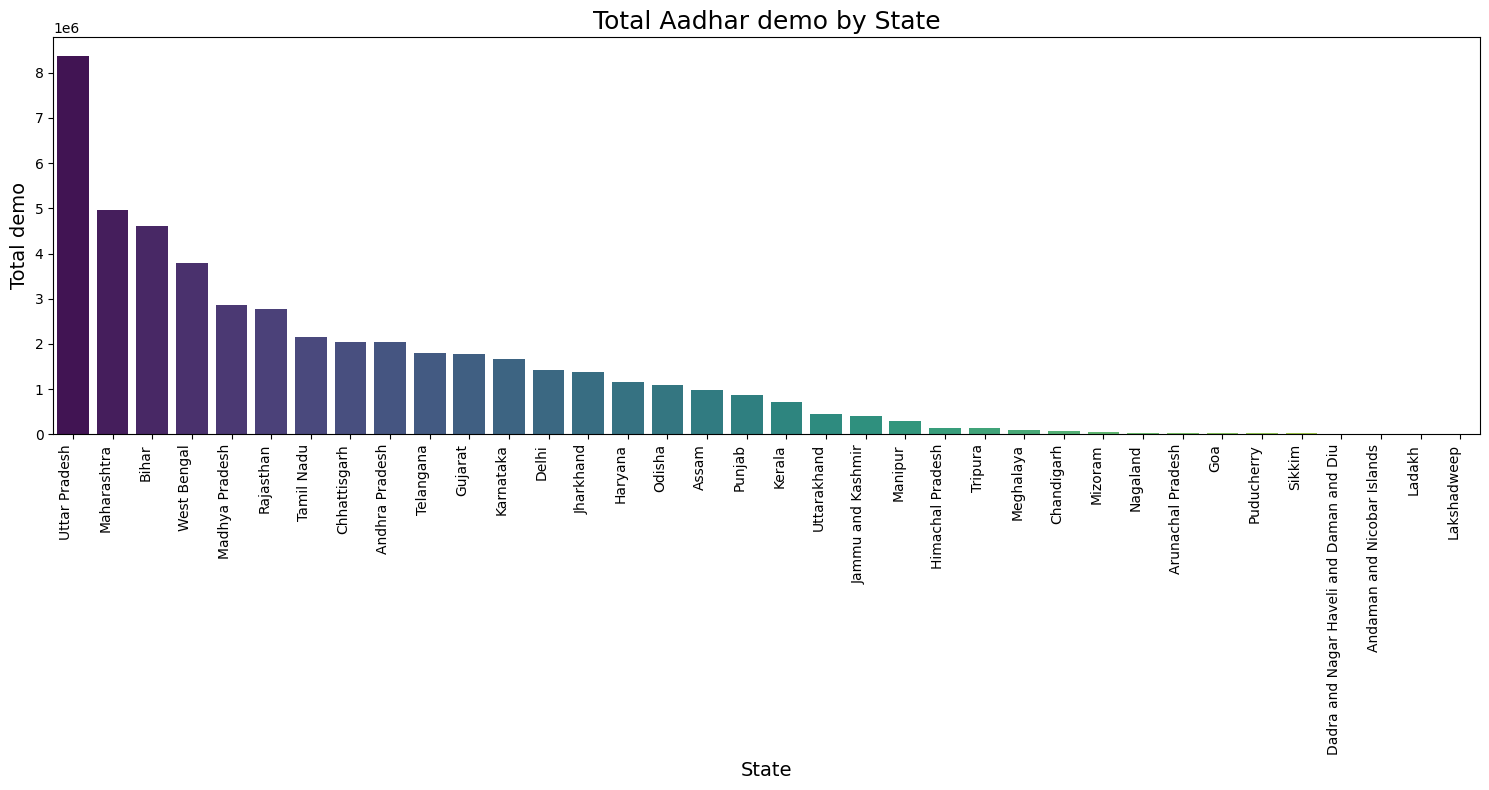

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 8)) # Adjusted figure size for better readability of bar graph
sns.barplot(
    x='state',
    y='total_demo',
    data=state_wise_total_demo,
    palette='viridis' # Choose a color palette
)
plt.title('Total Aadhar demo by State', fontsize=18)
plt.xlabel('State', fontsize=14)
plt.ylabel('Total demo', fontsize=14)
plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
selected_state = input("Enter the state name to generate a district-wise demo bar graph: ")
districts_in_selected_state = state_district_wise_total_demo[state_district_wise_total_demo['state'] == selected_state]
if not districts_in_selected_state.empty:
    districts_in_selected_state = districts_in_selected_state.sort_values(by='total_demo', ascending=False)
    plt.figure(figsize=(15, 8))
    sns.barplot(x='district', y='total_demo',
                data=districts_in_selected_state,
                palette='viridis'
                )

    plt.title(f'District-wise Aadhar demo in {selected_state}', fontsize=18)
    plt.xlabel('District', fontsize=14)
    plt.ylabel('Total demo', fontsize=14)
    plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
else:
    print(f"No data found for the state: {selected_state}. Please check the state name and try again.")

Enter the state name to generate a district-wise demo bar graph:  .


No data found for the state: .. Please check the state name and try again.


In [18]:
total_peope_all_days = combined_df.groupby(['state'])['total_demo'].sum()
count = combined_df.groupby(['state'])['total_demo'].count()

In [19]:
avg_people_each_state = total_peope_all_days/count
print(avg_people_each_state.sort_values(ascending=False))

state
Delhi                                       140.216046
Chhattisgarh                                 52.465899
Uttar Pradesh                                51.573517
Bihar                                        50.285711
Manipur                                      42.077306
Chandigarh                                   41.882503
Haryana                                      41.591396
Madhya Pradesh                               38.999333
Jharkhand                                    35.785777
Maharashtra                                  32.272756
Rajasthan                                    31.972876
West Bengal                                  23.313127
Uttarakhand                                  20.440608
Jammu and Kashmir                            20.028312
Gujarat                                      19.227073
Punjab                                       18.033895
Meghalaya                                    16.618746
Assam                                        16.307365
Trip

In [20]:
import numpy as np
import pandas as pd

In [21]:
import geopandas as gpd
from pyogrio import set_gdal_config_options
set_gdal_config_options({
    'SHAPE_RESTORE_SHX': 'YES',
})

In [22]:
fp = r'india-polygon.shp'
map_df = gpd.read_file(fp)
map_df_copy = gpd.read_file(fp)
map_df.head()

,id,st_nm,geometry
0,None,Andaman and Nicobar Islands,"MULTIPOLYGON (((93.84831 7.24028, 93.92705 7.0..."
1,None,Arunachal Pradesh,"POLYGON ((95.23643 26.68105, 95.19594 27.03612..."
2,None,Assam,"POLYGON ((95.19594 27.03612, 95.08795 26.94578..."
3,None,Bihar,"POLYGON ((88.11357 26.54028, 88.28006 26.3764,..."
4,None,Chandigarh,"POLYGON ((76.84208 30.76124, 76.83758 30.72552..."


In [23]:
map_df['st_nm']

0     Andaman and Nicobar Islands
1               Arunachal Pradesh
2                           Assam
3                           Bihar
4                      Chandigarh
5                    Chhattisgarh
6          Dadra and Nagar Haveli
7                   Daman and Diu
8                             Goa
9                         Gujarat
10                        Haryana
11               Himachal Pradesh
12                      Jharkhand
13                      Karnataka
14                         Kerala
15                    Lakshadweep
16                 Madhya Pradesh
17                    Maharashtra
18                        Manipur
19                      Meghalaya
20                        Mizoram
21                       Nagaland
22                          Delhi
23                     Puducherry
24                         Punjab
25                      Rajasthan
26                         Sikkim
27                     Tamil Nadu
28                      Telangana
29            

In [24]:
combined_df.to_csv("downloaded_Demo_Combined_data.csv", index=False)

In [25]:
df = pd.read_csv('downloaded_Demo_Combined_data.csv')
total_peope_all_days = df.groupby(['state'])['total_demo'].sum()
count = df.groupby(['state'])['total_demo'].count()
avg_people_all_day = total_peope_all_days/count
merged = map_df.set_index('st_nm').join(avg_people_all_day)
merged

,id,geometry,total_demo
st_nm,,,
Andaman and Nicobar Islands,None,"MULTIPOLYGON (((93.84831 7.24028, 93.92705 7.0...",4.227053
Arunachal Pradesh,None,"POLYGON ((95.23643 26.68105, 95.19594 27.03612...",7.812078
Assam,None,"POLYGON ((95.19594 27.03612, 95.08795 26.94578...",16.307365
Bihar,None,"POLYGON ((88.11357 26.54028, 88.28006 26.3764,...",50.285711
Chandigarh,None,"POLYGON ((76.84208 30.76124, 76.83758 30.72552...",41.882503
Chhattisgarh,None,"POLYGON ((83.94694 23.62196, 83.95594 23.62406...",52.465899
Dadra and Nagar Haveli,None,"POLYGON ((73.2064 20.12165, 73.20865 20.10695,...",NaN
Daman and Diu,None,"POLYGON ((72.80144 20.37378, 72.84418 20.47463...",NaN
Goa,None,"POLYGON ((74.11982 15.65278, 74.24806 15.65698...",5.966825


In [26]:
import matplotlib.pyplot as plt

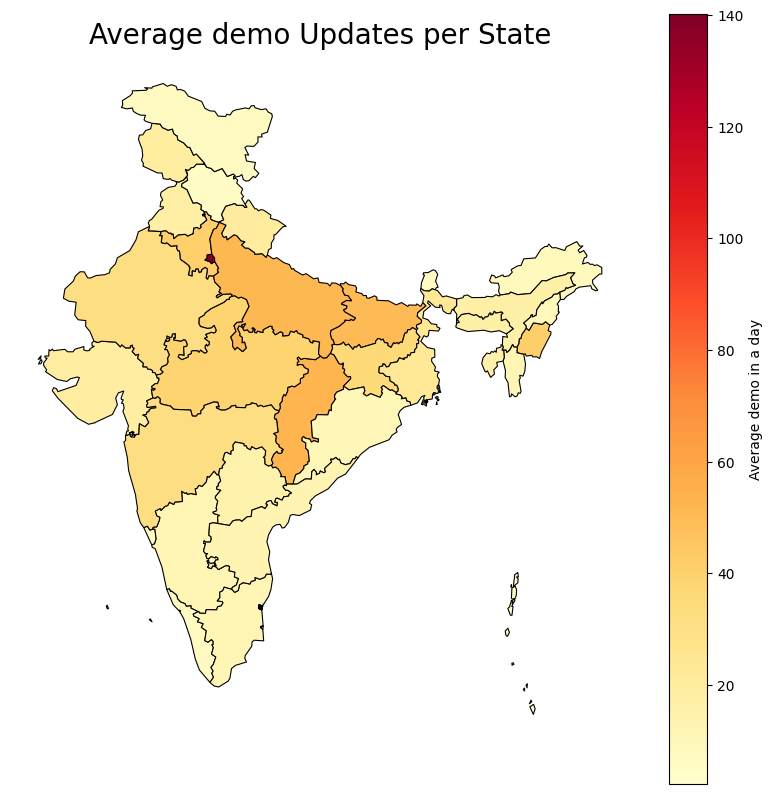

In [37]:
# fig, ax = plt.subplots(1, figsize=(10, 10))
# ax.axis('off')

# ax.set_title(
#     'Average Biometric Updates per State',
#     fontdict={'fontsize': '20', 'fontweight': '10'}
# )

# # Plot heatmap
# merged.plot(
#     column='total_biometric',
#     cmap='YlOrRd',
#     linewidth=0.8,
#     ax=ax,
#     edgecolor='0',
#     legend=True,
#     legend_kwds={'label': "Average biometric in a day"}
# )

# # Save as SVG
# fig.savefig("heatmap_biometric.svg", format="svg", bbox_inches="tight")

# plt.show()

fig, ax = plt.subplots(1, figsize=(10, 10))
ax.axis('off')
ax.set_title('Average demo Updates per State', fontdict={'fontsize': '20', 'fontweight' : '10'})
# Plot the figure
merged.plot(column='total_demo', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0', legend=True, legend_kwds={'label': "Average demo in a day"})
plt.savefig("heatmap_demo.svg")
plt.show()

In [28]:
print(avg_people_each_state.sort_values(ascending=False))

state
Delhi                                       140.216046
Chhattisgarh                                 52.465899
Uttar Pradesh                                51.573517
Bihar                                        50.285711
Manipur                                      42.077306
Chandigarh                                   41.882503
Haryana                                      41.591396
Madhya Pradesh                               38.999333
Jharkhand                                    35.785777
Maharashtra                                  32.272756
Rajasthan                                    31.972876
West Bengal                                  23.313127
Uttarakhand                                  20.440608
Jammu and Kashmir                            20.028312
Gujarat                                      19.227073
Punjab                                       18.033895
Meghalaya                                    16.618746
Assam                                        16.307365
Trip

C:\Users\kshit\AppData\Local\Temp\ipykernel_9560\1249281806.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state',y='average_demo',


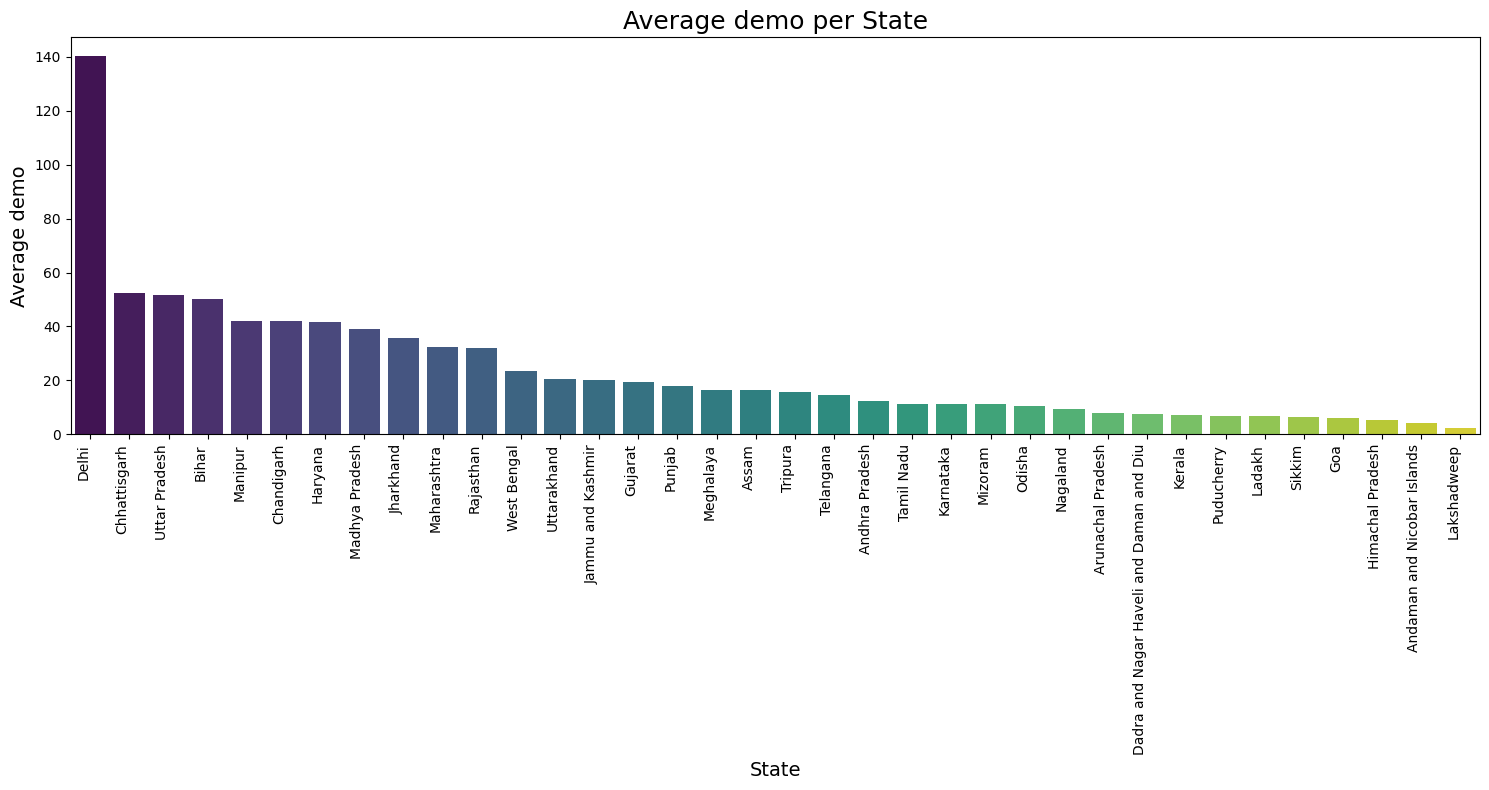

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8)) # Adjusted figure size for a bar graph
plt.title('Average demo per State', fontsize=18)
plt.xlabel('State', fontsize=14)
plt.ylabel('Average demo', fontsize=14)
avg_people_each_state_df = avg_people_each_state.reset_index()
avg_people_each_state_df.columns = ['state', 'average_demo']
sns.barplot(x='state',y='average_demo',
    data=avg_people_each_state_df.sort_values(by='average_demo', ascending=False),
    palette='viridis'
)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.savefig("demo_by_state_graph.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
total_peope_of_age_5_17= combined_df.groupby(['state'])['demo_age_5_17'].sum()     #'bio_age_5_17'  'bio_age_17_'
count1= combined_df.groupby(['state'])['demo_age_5_17'].count()
avg_people_of_age_5_17= total_peope_of_age_5_17/count1
total_peope_of_age_17_= combined_df.groupby(['state'])['demo_age_17_'].sum()
count2= combined_df.groupby(['state'])['demo_age_17_'].count()
avg_people_of_age_17_ = total_peope_of_age_17_/count2

C:\Users\kshit\AppData\Local\Temp\ipykernel_9560\1169776028.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_people_of_age_5_17.index, y=avg_people_of_age_5_17.values, ax=ax[0], palette='viridis')
C:\Users\kshit\AppData\Local\Temp\ipykernel_9560\1169776028.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_people_of_age_17_.index, y=avg_people_of_age_17_.values, ax=ax[1], palette='magma')


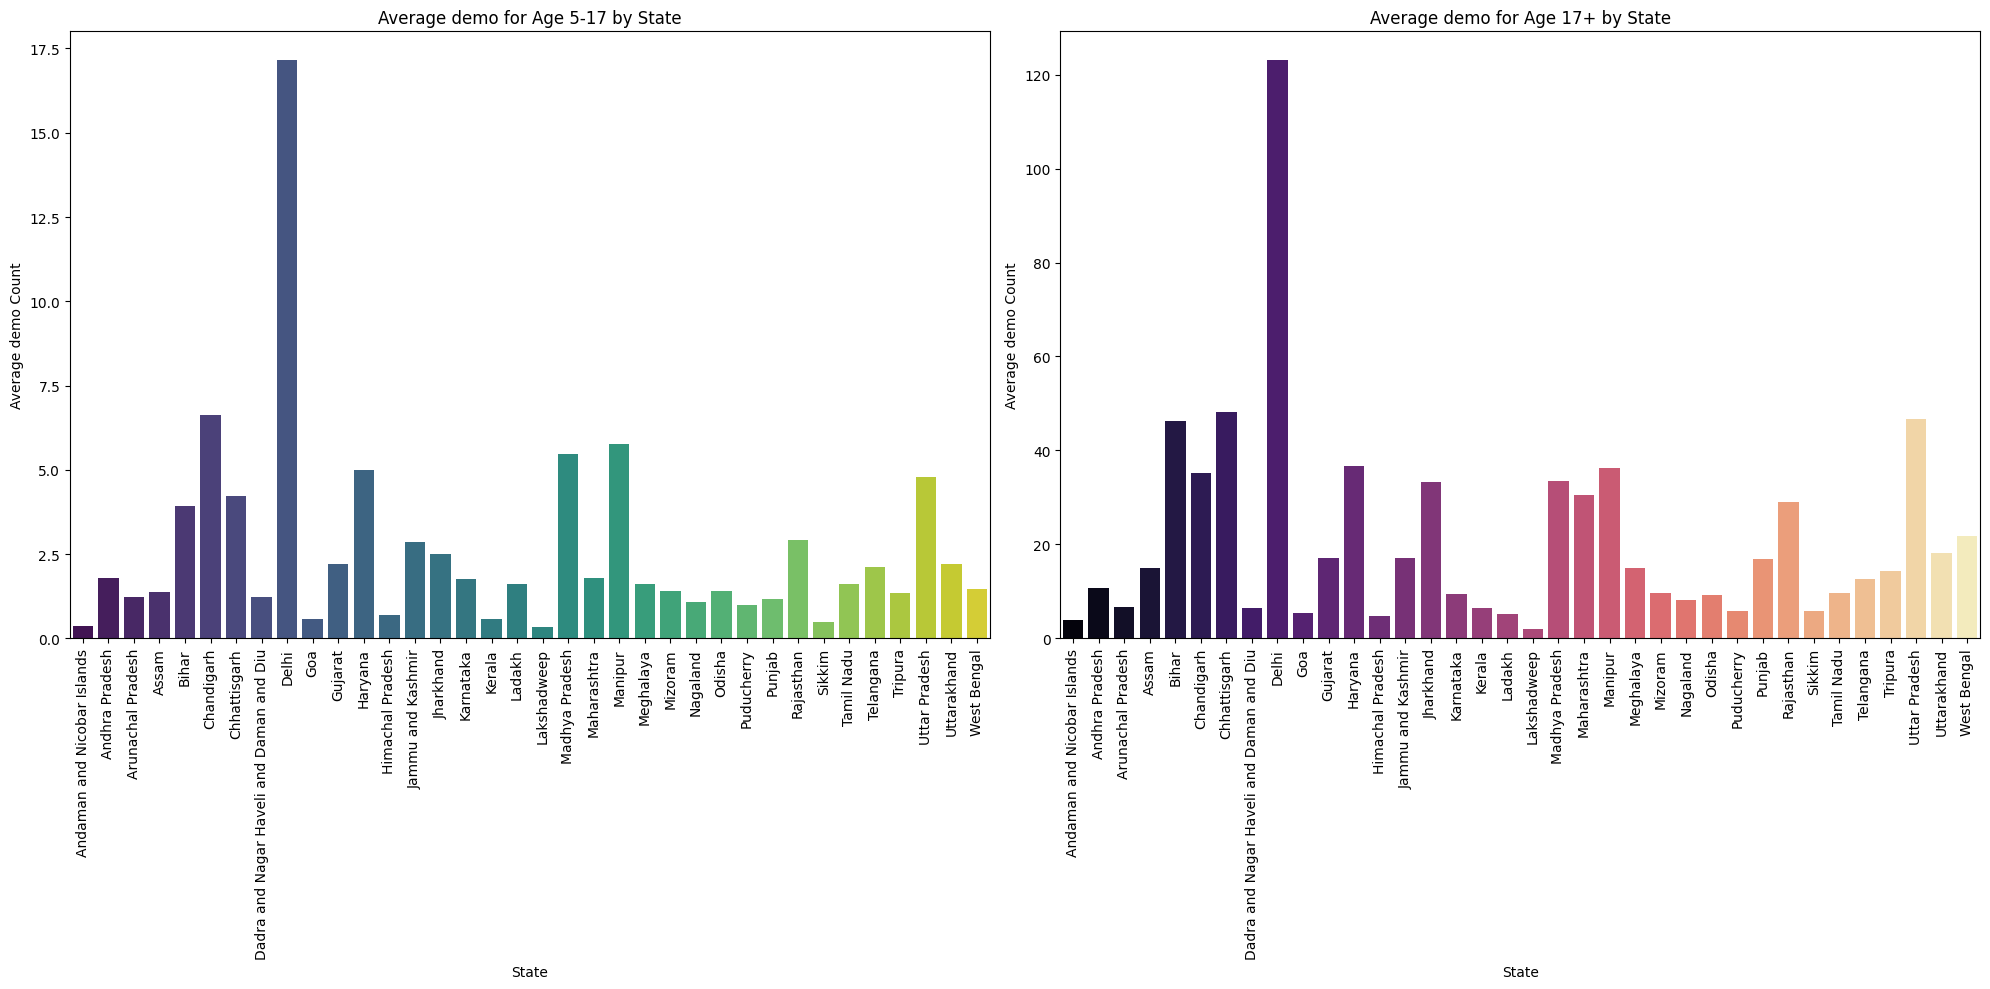

In [36]:
import seaborn as sns, matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 10)) # Adjusted figure size to be wider and shorter
fig.subplots_adjust(wspace=0.5) # Adjust space between subplots

# Plot for avg_people_of_age_5_17
sns.barplot(x=avg_people_of_age_5_17.index, y=avg_people_of_age_5_17.values, ax=ax[0], palette='viridis')
ax[0].set_title('Average demo for Age 5-17 by State')
ax[0].set_xlabel('State')
ax[0].set_ylabel('Average demo Count')
ax[0].tick_params(axis='x', rotation=90) # Rotate x-axis labels

# Plot for avg_people_of_age_17_
sns.barplot(x=avg_people_of_age_17_.index, y=avg_people_of_age_17_.values, ax=ax[1], palette='magma')
ax[1].set_title('Average demo for Age 17+ by State')
ax[1].set_xlabel('State')
ax[1].set_ylabel('Average demo Count')
ax[1].tick_params(axis='x', rotation=90) # Rotate x-axis labels

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig("age_demo_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

Enter the state name to generate district-wise average demo graphs:  Delhi


C:\Users\kshit\AppData\Local\Temp\ipykernel_9560\120174847.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_avg_5_17.index, y=district_avg_5_17.values, ax=ax[0], palette='viridis')
C:\Users\kshit\AppData\Local\Temp\ipykernel_9560\120174847.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_avg_17_.index, y=district_avg_17_.values, ax=ax[1], palette='magma')


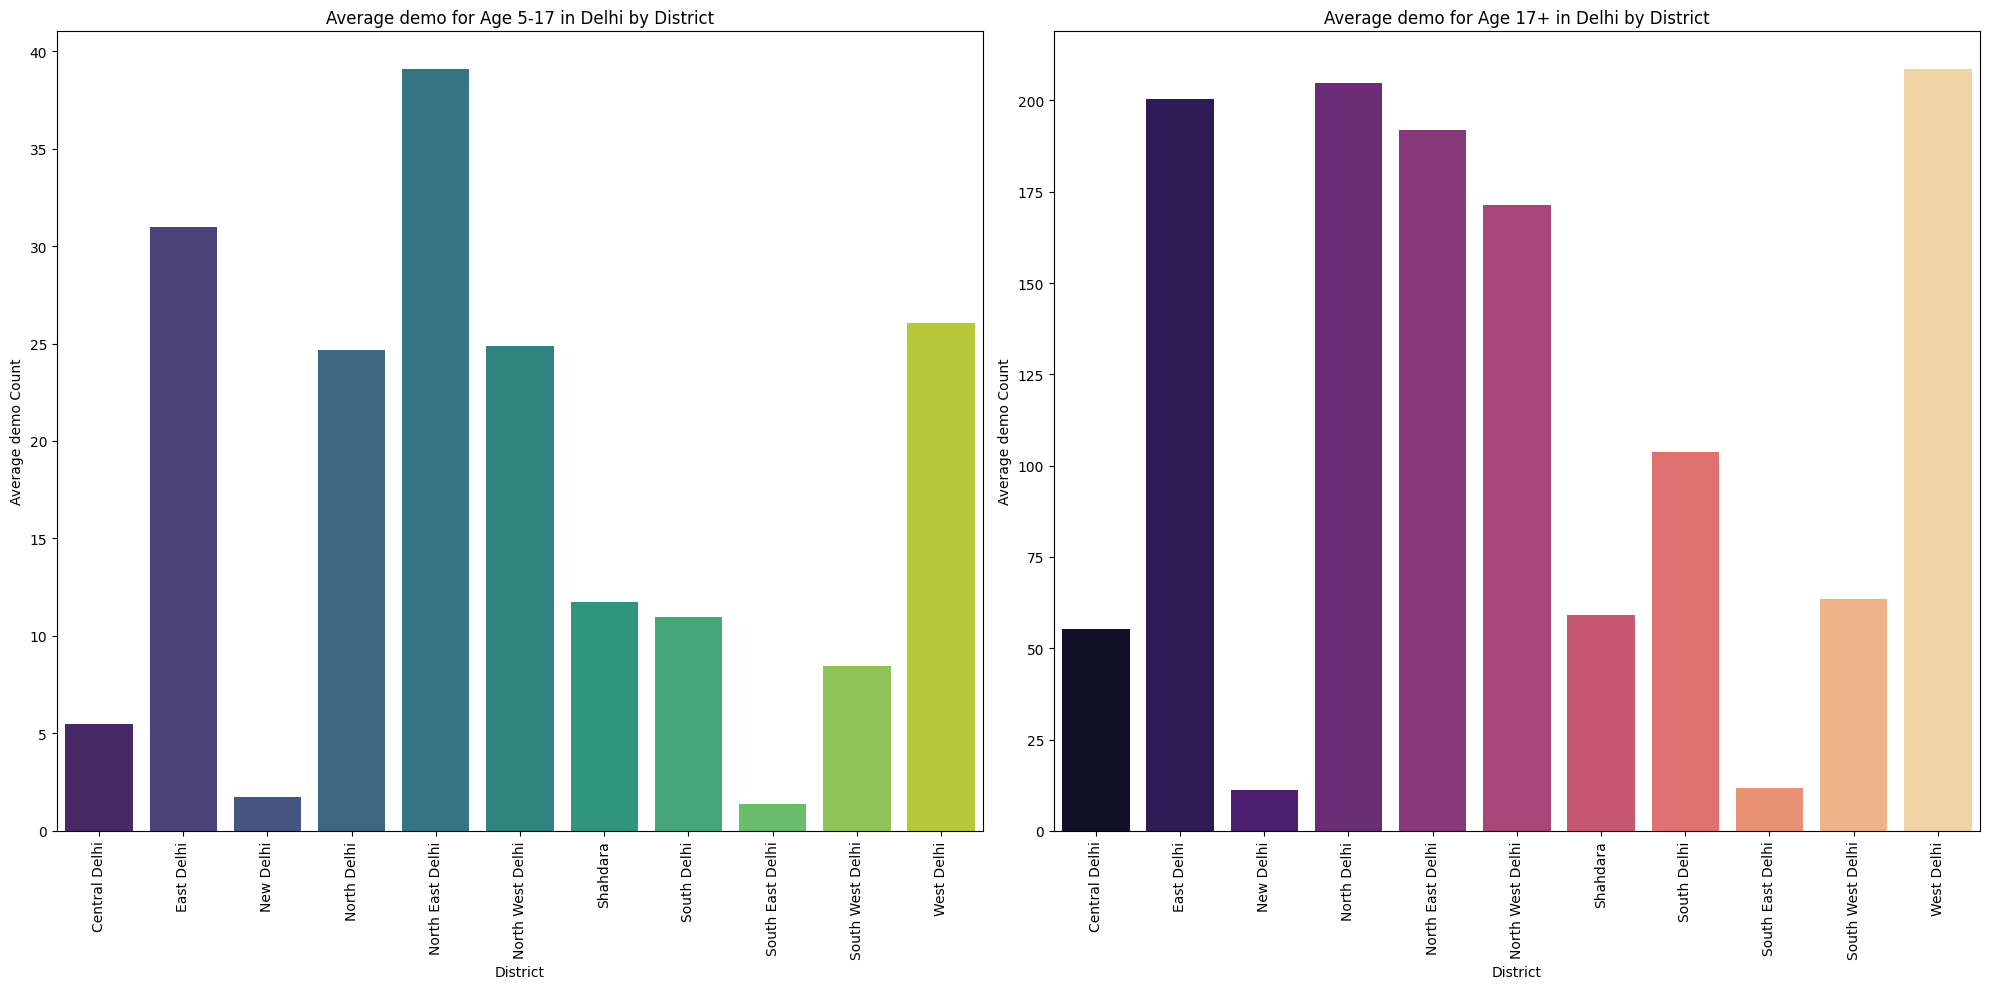

In [33]:
selected_state_for_district = input("Enter the state name to generate district-wise average demo graphs: ")
df_filtered_state = combined_df[combined_df['state'] == selected_state_for_district]
if not df_filtered_state.empty:
    district_avg_5_17 = df_filtered_state.groupby('district')['demo_age_5_17'].sum() / df_filtered_state.groupby('district')['demo_age_5_17'].count()
    district_avg_17_ = df_filtered_state.groupby('district')['demo_age_17_'].sum() / df_filtered_state.groupby('district')['demo_age_17_'].count()
    fig, ax = plt.subplots(1, 2, figsize=(20, 10)) # Adjusted figure size
    fig.subplots_adjust(wspace=0.5)
    sns.barplot(x=district_avg_5_17.index, y=district_avg_5_17.values, ax=ax[0], palette='viridis')
    ax[0].set_title(f'Average demo for Age 5-17 in {selected_state_for_district} by District')
    ax[0].set_xlabel('District')
    ax[0].set_ylabel('Average demo Count')
    ax[0].tick_params(axis='x', rotation=90)
    sns.barplot(x=district_avg_17_.index, y=district_avg_17_.values, ax=ax[1], palette='magma')
    ax[1].set_title(f'Average demo for Age 17+ in {selected_state_for_district} by District')
    ax[1].set_xlabel('District')
    ax[1].set_ylabel('Average demo Count')
    ax[1].tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print(f"No data found for the state: {selected_state_for_district}. Please check the state name and try again.")